In [1]:
pip install notebook pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
#Import Libraries
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
#Create & Connect Database
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

print("Database connected successfully!")

Database connected successfully!


In [5]:
#Create Sales Table
cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT,
    quantity INTEGER,
    price REAL
)
""")

print("Table created!")

Table created!


In [6]:
#Insert Sample Data
cursor.execute("DELETE FROM sales")

data = [
    ("Laptop", 5, 50000),
    ("Mouse", 20, 500),
    ("Keyboard", 15, 800),
    ("Laptop", 3, 52000),
    ("Mouse", 10, 550),
    ("Keyboard", 7, 750)
]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", data)
conn.commit()

print("Sample data inserted!")

Sample data inserted!


In [7]:
#Run SQL Query (Main Task)
query = """
SELECT product,
       SUM(quantity) AS total_quantity,
       SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

df = pd.read_sql_query(query, conn)
df

,product,total_quantity,revenue
0,Keyboard,22,17250.0
1,Laptop,8,406000.0
2,Mouse,30,15500.0


In [8]:
print("Sales Summary:")
print(df)

Sales Summary:
    product  total_quantity   revenue
0  Keyboard              22   17250.0
1    Laptop               8  406000.0
2     Mouse              30   15500.0


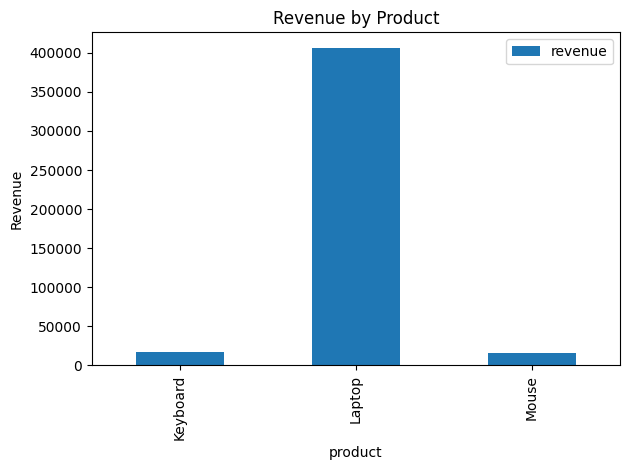

In [11]:
#BAR CHAR
df.plot(kind='bar', x='product', y='revenue', title='Revenue by Product')
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()


In [12]:
conn.close()
print("Database connection closed.")

Database connection closed.
